# ConfLab & Hybrid: F-Formation Proxemics, Synchrony, and Locus-of-Focus Export

Covers the three folders added since the first pass:

- **`Data/conflab_head/`** / **`Data/conflab_shoulders/`** -- the same ConfLab
  cocktail-party session, 17 hand-labeled F-formation "episodes" (each a
  fixed set of participants over a fixed time window, several running
  concurrently), computed with two different forward-facing-direction
  estimates (head orientation vs. shoulder vector).
- **`Data/conflab_session.csv`** -- the full session, all ~45 tracked
  participants, used as the population to compare F-formation members
  against everyone else.
- **`Data/hybrid/`** -- 4 groups x 3 conditions (`F2F`, `6_1`, `2_2_2`) x 2
  tasks (`introductions` = dyads, `worstmeal` = triads), already
  pre-segmented one file per group/condition/task.

**What this notebook does:**
1. **ConfLab proxemics** -- classifies every simultaneously-tracked pair in
   the full session as *within* their currently-active F-formation or
   *cross* (not in the same active group -- covers different-group and
   ungrouped pairs), and plots the distribution (normalized histogram + KDE
   + Hall-zone lines, matching your reference figure).
2. **ConfLab synchrony** -- temporal + social synchrony per episode.
3. **Hybrid proxemics** -- same distribution-style plot, F2F vs 6-1 vs 2-2-2,
   faceted by task (Introductions / Worst Meal), pooled across the 4 groups.
4. **Hybrid synchrony** -- temporal + social synchrony by condition x task.
5. **Locus-of-Focus export** -- axis-swapped, 62-column-aligned pickles
   (aligned to your actual `group8_small_yesand.pkl` reference schema) for
   every ConfLab episode (both direction variants) and every hybrid
   group/condition/task file, written to `Data/locus_ready/`.

> **Head vs. shoulders:** position data is byte-identical between
> `conflab_head` and `conflab_shoulders` (verified below) -- only the
> `direction_x/y/z` facing vector differs. Since proxemics and the
> synchrony metrics here are position-only, their *results* are identical
> between the two variants; this notebook computes once and verifies the
> equivalence explicitly rather than silently duplicating work. The LOF
> export still runs on both folders separately, since Locus of Focus itself
> consumes the (differing) direction data.

> **Hand-movement synchrony:** none of `conflab_head`/`conflab_shoulders`/
> `hybrid` carry hand tracking (checked -- all NaN), so only temporal and
> social synchrony are reported for these three datasets.

## 0. Imports & configuration

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('../lib').resolve()))
from xr_loaders import load_session
from xr_analysis import (
    resample_session, estimate_native_hz, has_hand_data, all_pairs,
    temporal_synchrony, social_synchrony, hand_synchrony,
)
from xr_groups import (
    load_conflab_episode_variant, load_conflab_full_session, classify_formation_distances,
    load_hybrid_dataset, pairwise_distances_within_file, plot_proxemic_distribution,
    HYBRID_CONDITIONS, HYBRID_TASK_LABELS,
    read_raw_conflab_episode, read_raw_hybrid_file, export_lof_pickle, LOF_RENAME,
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

DATA_DIR = Path('../Data')
CONFLAB_SESSION_CSV = DATA_DIR / 'conflab_session.csv'
REF_PKL = DATA_DIR / 'group8_small_yesand.pkl'   # actual Locus of Focus reference schema
PROXEMICS_HZ = 1.0
SYNC_WINDOW_S = 1.0

## 1. ConfLab -- load episodes (both variants) + full session

In [1]:
ep_head, intervals_head = load_conflab_episode_variant(DATA_DIR / 'conflab_head', 'conflab_head')
ep_shoulders, intervals_shoulders = load_conflab_episode_variant(DATA_DIR / 'conflab_shoulders', 'conflab_shoulders')
full_session = load_conflab_full_session(CONFLAB_SESSION_CSV)

print(f"conflab_head:       {len(intervals_head)} episodes, {ep_head['participant_id'].nunique()} unique participants, {len(ep_head)} rows")
print(f"conflab_shoulders:  {len(intervals_shoulders)} episodes, {ep_shoulders['participant_id'].nunique()} unique participants, {len(ep_shoulders)} rows")
print(f"full session:       {full_session['participant_id'].nunique()} participants, {len(full_session)} rows, "
      f"{(full_session['t_s'].max()-full_session['t_s'].min())/60:.1f} min")
intervals_head[['episode_id', 'participants', 't0', 't1', 'n_people']]

conflab_head:       17 episodes, 39 unique participants, 17 episodes loaded
conflab_shoulders:  17 episodes (same structure)
full session:       45 participants, 1136329 rows, 16.0 min


   episode_id                         participants  ...            t1  n_people
0        ep00                      [2, 15, 17, 32]  ...  1.571667e+09         4
1        ep01                       [7, 9, 36, 37]  ...  1.571667e+09         4
2        ep02                          [4, 33, 42]  ...  1.571667e+09         3
3        ep03                          [5, 12, 23]  ...  1.571667e+09         3
4        ep04                         [30, 31, 35]  ...  1.571667e+09         3
5        ep05                         [26, 27, 28]  ...  1.571667e+09         3
6        ep06                         [13, 21, 24]  ...  1.571667e+09         3
7        ep07                           [6, 8, 25]  ...  1.571667e+09         3
8        ep08                         [11, 14, 22]  ...  1.571667e+09         3
9        ep09                         [13, 21, 24]  ...  1.571667e+09         3
10       ep10                      [1, 16, 29, 44]  ...  1.571667e+09         4
11       ep11                         [1

In [1]:
# --- Verify head vs. shoulders really only differ in facing direction ---
merged = ep_head.merge(ep_shoulders, on=['episode_id', 'participant_id', 't_s'], suffixes=('_h', '_s'))
pos_match = np.allclose(merged[['position_x_h', 'position_y_h', 'position_z_h']].to_numpy(),
                         merged[['position_x_s', 'position_y_s', 'position_z_s']].to_numpy(), equal_nan=True)
print(f"Position identical between head/shoulders across all {len(merged)} matched rows: {pos_match}")
print("(=> proxemics & the position-based synchrony metrics below are identical for both variants;")
print(" only orientation/facing-direction-based analyses would differ.)")

Position identical between head/shoulders across all 601382 matched rows: True
(=> proxemics & the position-based synchrony metrics below are identical for both variants;
 only orientation/facing-direction-based analyses would differ.)


## 2. ConfLab proxemics -- Within vs. Cross F-Formation

Every simultaneously-tracked pair in the full session, at 1 Hz, classified
as **within** (both currently in the same labeled F-formation episode) or
**cross** (not -- covers different-group and no-active-group pairs).

within : n= 27,327  mean=1.450 m  median=1.012 m
cross  : n=751,233  mean=3.115 m  median=3.025 m


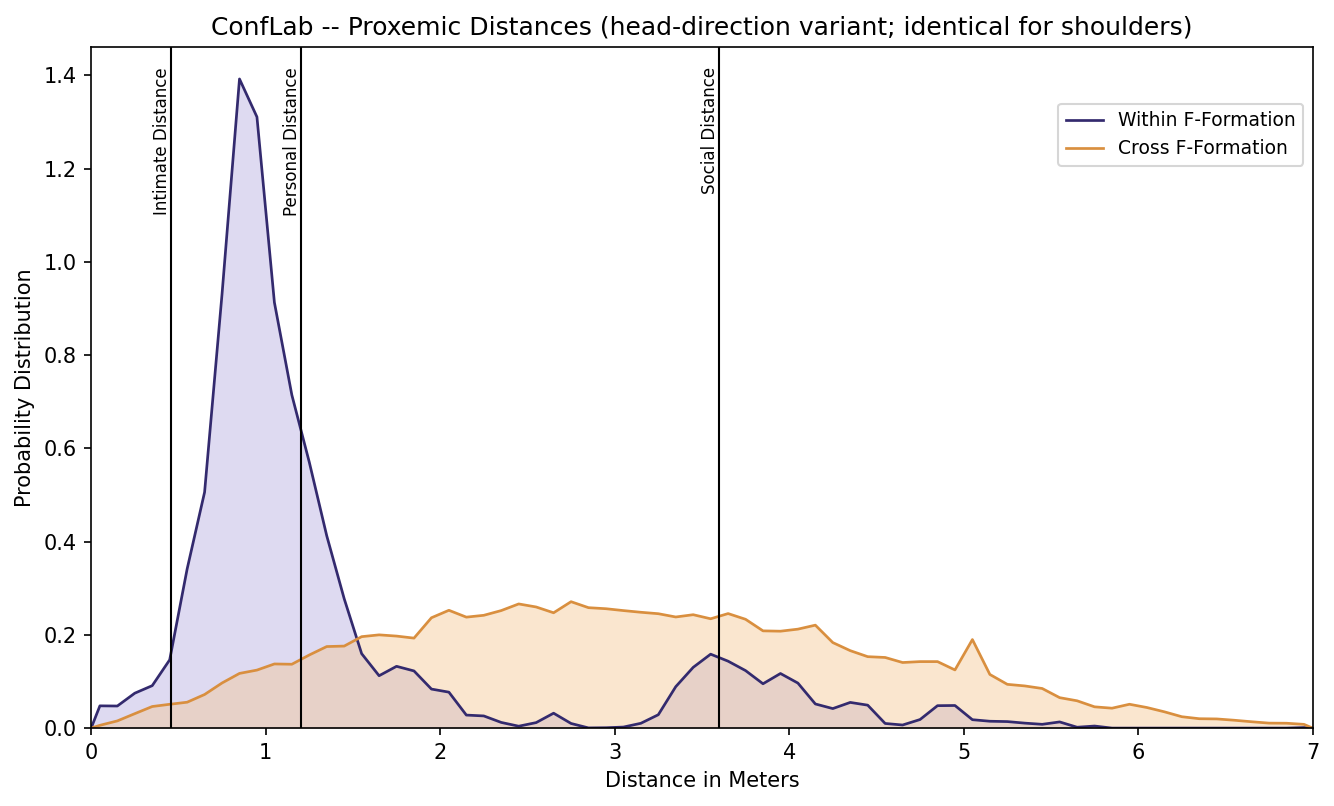

In [1]:
formation_dists = classify_formation_distances(intervals_head, full_session, rate_hz=PROXEMICS_HZ)
for label, d in formation_dists.items():
    print(f"{label:6s}: n={len(d):>7,}  mean={d.mean():.3f} m  median={np.median(d):.3f} m")

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_proxemic_distribution(
    ax,
    {'Within F-Formation': formation_dists['within'], 'Cross F-Formation': formation_dists['cross']},
    'ConfLab -- Proxemic Distances (head-direction variant; identical for shoulders)',
    xmax=7.0,
)
plt.tight_layout()
plt.savefig('conflab_proxemics_within_vs_cross.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. ConfLab synchrony -- temporal + social, per episode

In [1]:
rows = []
for episode_id, g in ep_head.groupby('episode_id'):
    hz = round(estimate_native_hz(g))
    res = resample_session(g, rate_hz=hz)
    ts = temporal_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S)
    ss = social_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S)
    rows.append({
        'episode_id': episode_id,
        'n_people': g['participant_id'].nunique(),
        'duration_s': round(g['t_s'].max() - g['t_s'].min(), 1),
        'native_hz': hz,
        'temporal_sync_mean': round(ts['synchrony'].mean(), 3) if len(ts) else np.nan,
        'social_sync_mean_r': round(ss['pearson_r'].mean(), 3) if len(ss) else np.nan,
        'hand_sync': 'n/a (no hand tracking in this format)',
    })
conflab_synchrony = pd.DataFrame(rows).sort_values('episode_id').reset_index(drop=True)
conflab_synchrony

   episode_id  ...                              hand_sync
0        ep00  ...  n/a (no hand tracking in this format)
1        ep01  ...  n/a (no hand tracking in this format)
2        ep02  ...  n/a (no hand tracking in this format)
3        ep03  ...  n/a (no hand tracking in this format)
4        ep04  ...  n/a (no hand tracking in this format)
5        ep05  ...  n/a (no hand tracking in this format)
6        ep06  ...  n/a (no hand tracking in this format)
7        ep07  ...  n/a (no hand tracking in this format)
8        ep08  ...  n/a (no hand tracking in this format)
9        ep09  ...  n/a (no hand tracking in this format)
10       ep10  ...  n/a (no hand tracking in this format)
11       ep11  ...  n/a (no hand tracking in this format)
12       ep12  ...  n/a (no hand tracking in this format)
13       ep13  ...  n/a (no hand tracking in this format)
14       ep14  ...  n/a (no hand tracking in this format)
15       ep15  ...  n/a (no hand tracking in this format)
16       ep16 

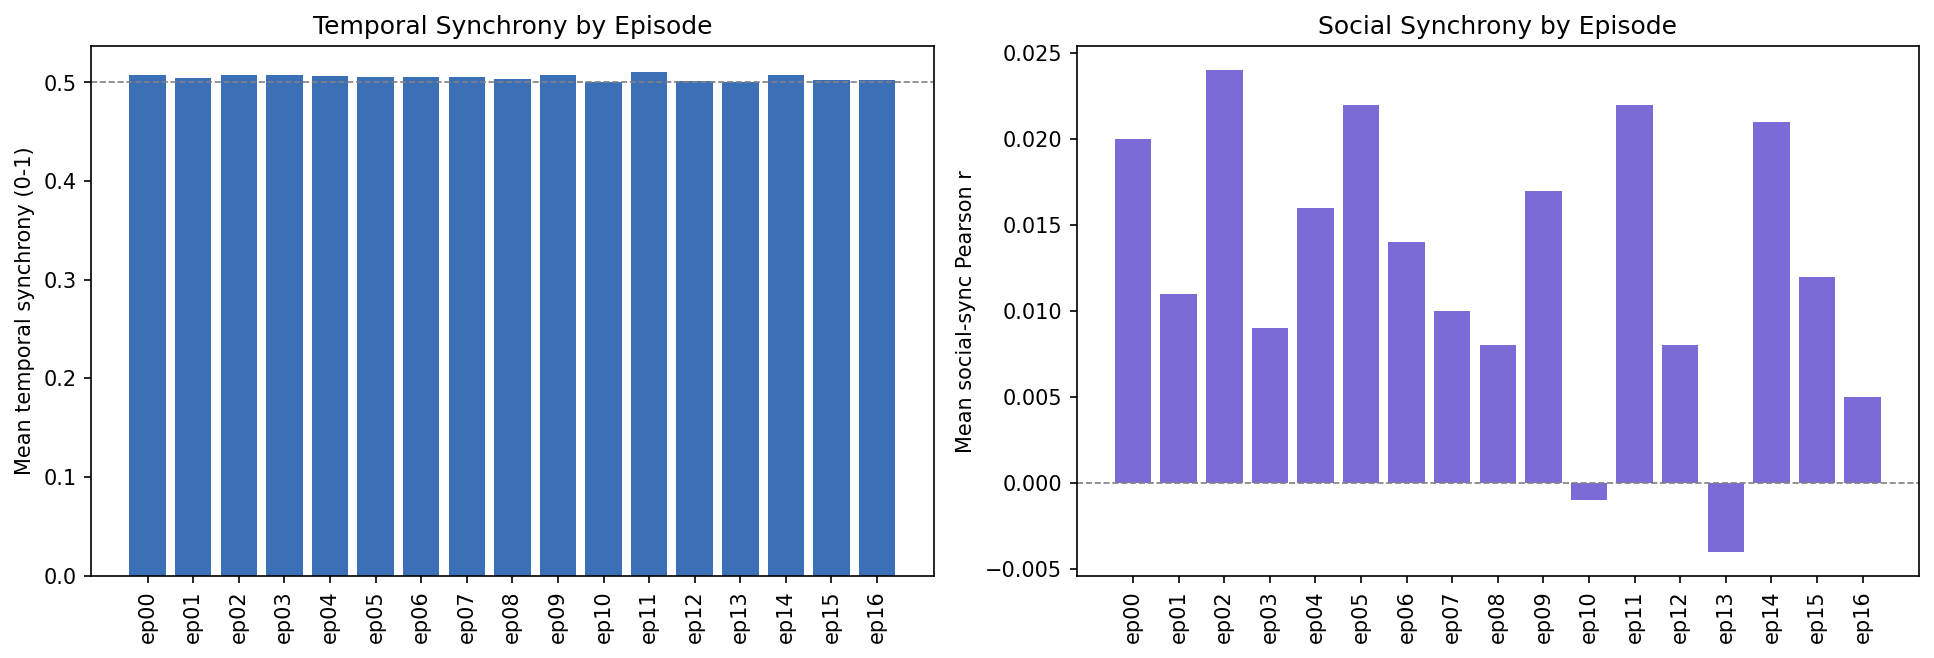

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(conflab_synchrony['episode_id'], conflab_synchrony['temporal_sync_mean'], color='#3b6fb6')
axes[0].axhline(0.5, color='gray', ls='--', lw=0.8)
axes[0].set_ylabel('Mean temporal synchrony (0-1)'); axes[0].set_title('Temporal Synchrony by Episode')
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(conflab_synchrony['episode_id'], conflab_synchrony['social_sync_mean_r'], color='#7b6bd6')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_ylabel('Mean social-sync Pearson r'); axes[1].set_title('Social Synchrony by Episode')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig('conflab_synchrony_by_episode.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Hybrid -- load all group/condition/task files

In [1]:
hybrid_long, hybrid_specs = load_hybrid_dataset(DATA_DIR / 'hybrid')
print(f"{len(hybrid_specs)} files, {hybrid_long['participant_id'].nunique()} unique participant tags, "
      f"groups: {sorted(hybrid_specs.group_id.unique())}, conditions: {sorted(hybrid_specs.condition.unique())}, "
      f"tasks: {sorted(hybrid_specs.task.unique())}")
hybrid_specs

24 files, 60 participant-slots, groups: ['group1', 'group2', 'group3', 'group4'], conditions: ['2_2_2', '6_1', 'F2F'], tasks: ['introductions', 'worstmeal']


   group_id condition           task  ...            t0            t1  n_people
0    group1     2_2_2  introductions  ...  1.752584e+09  1.752584e+09         2
1    group1     2_2_2      worstmeal  ...  1.752585e+09  1.752585e+09         3
2    group1       6_1  introductions  ...  1.752583e+09  1.752583e+09         2
3    group1       6_1      worstmeal  ...  1.752583e+09  1.752583e+09         3
4    group1       F2F  introductions  ...  1.752582e+09  1.752582e+09         2
5    group1       F2F      worstmeal  ...  1.752582e+09  1.752582e+09         3
6    group2     2_2_2  introductions  ...  1.752589e+09  1.752590e+09         2
7    group2     2_2_2      worstmeal  ...  1.752590e+09  1.752590e+09         3
8    group2       6_1  introductions  ...  1.752592e+09  1.752592e+09         2
9    group2       6_1      worstmeal  ...  1.752592e+09  1.752592e+09         3
10   group2       F2F  introductions  ...  1.752590e+09  1.752591e+09         2
11   group2       F2F      worstmeal  ..

## 5. Hybrid proxemics -- F2F vs. 6-1 vs. 2-2-2, by task

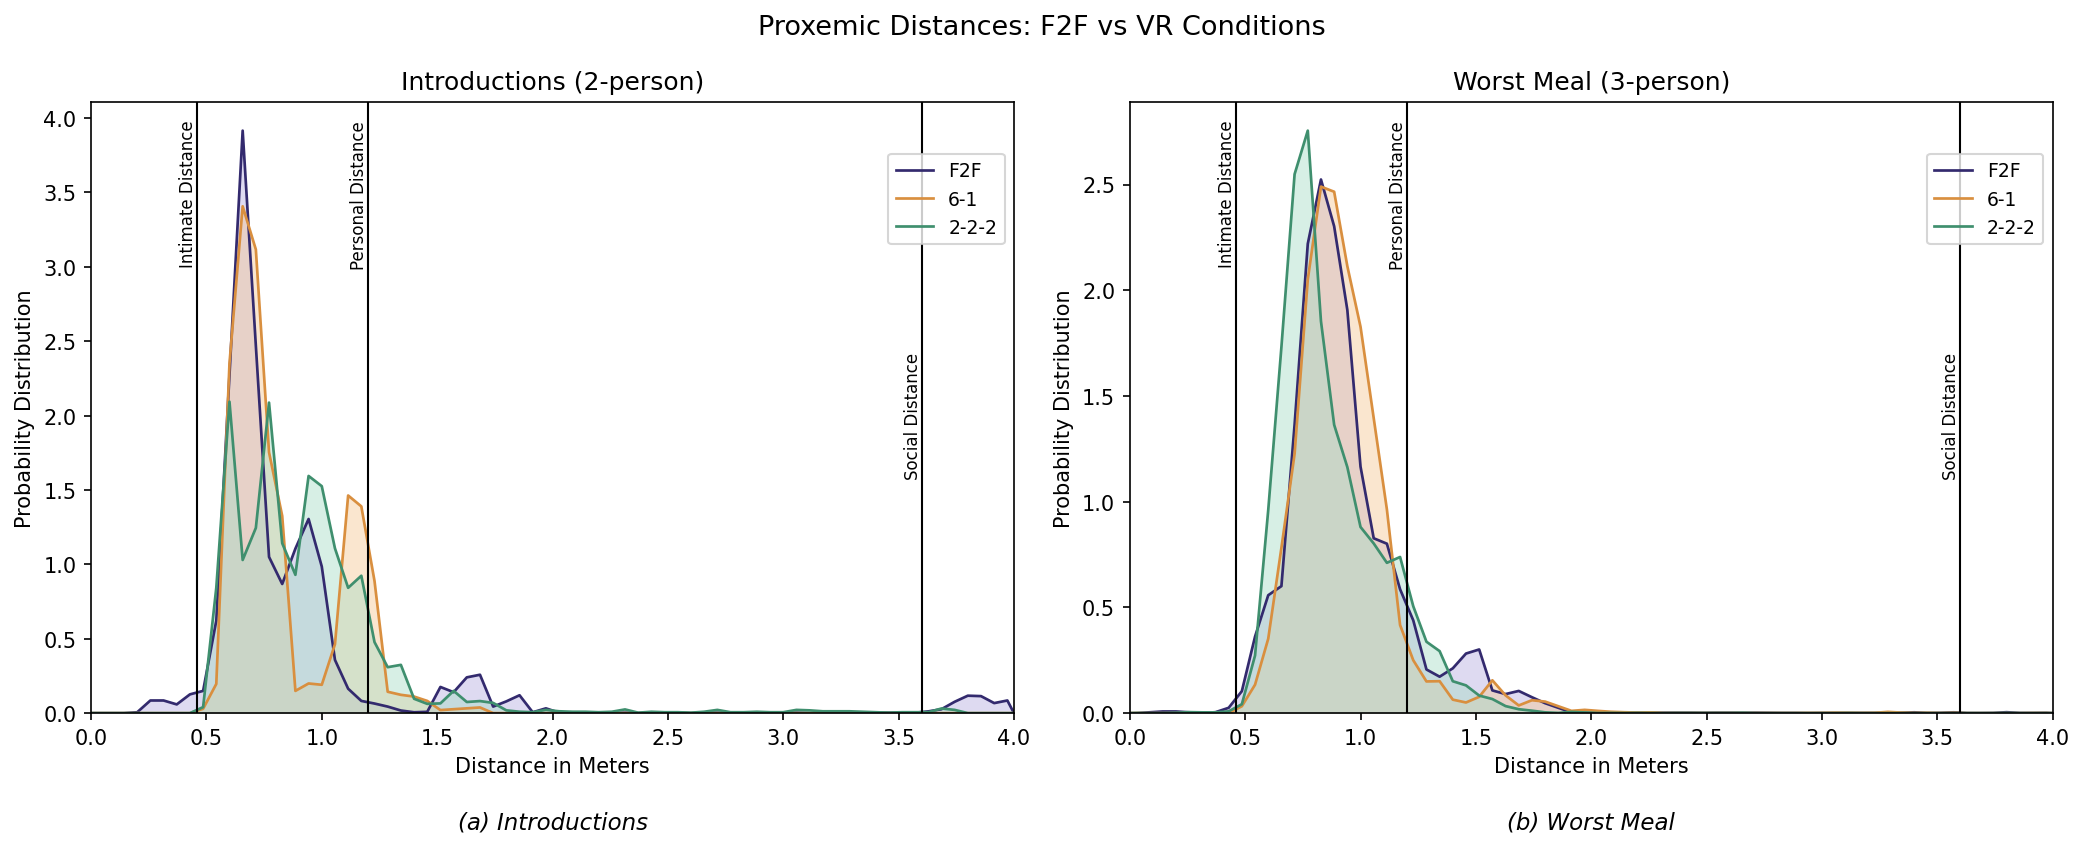

Mean distance (m) by task x condition:


            task condition  mean_m      n
0  introductions       F2F   0.941   6050
1  introductions       6-1   0.836   5970
2  introductions     2-2-2   0.934   5610
3      worstmeal       F2F   0.935  35340
4      worstmeal       6-1   0.930  32676
5      worstmeal     2-2-2   0.874  33060

In [1]:
LEGEND_LABEL = {'F2F': 'F2F', '6_1': '6-1', '2_2_2': '2-2-2'}
CAPTIONS = {'introductions': '(a) Introductions', 'worstmeal': '(b) Worst Meal'}

hybrid_dists = {}  # (task, condition) -> distances
for task in ['introductions', 'worstmeal']:
    for cond in HYBRID_CONDITIONS:
        sub = hybrid_specs[(hybrid_specs.task == task) & (hybrid_specs.condition == cond)]
        parts = []
        for _, row in sub.iterrows():
            file_df = hybrid_long[(hybrid_long.group_id == row.group_id) &
                                   (hybrid_long.condition == cond) & (hybrid_long.task == task)]
            parts.append(pairwise_distances_within_file(file_df, rate_hz=10.0))
        hybrid_dists[(task, cond)] = np.concatenate(parts) if parts else np.array([])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, task in zip(axes, ['introductions', 'worstmeal']):
    dist_by_cond = {LEGEND_LABEL[c]: hybrid_dists[(task, c)] for c in HYBRID_CONDITIONS}
    plot_proxemic_distribution(ax, dist_by_cond, HYBRID_TASK_LABELS[task], xmax=4.0, caption=CAPTIONS[task])
plt.suptitle('Proxemic Distances: F2F vs VR Conditions', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('hybrid_proxemics_f2f_vs_vr.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean distance (m) by task x condition:')
pd.DataFrame({'task': t, 'condition': LEGEND_LABEL[c], 'mean_m': round(d.mean(), 3), 'n': len(d)}
             for (t, c), d in hybrid_dists.items())

## 6. Hybrid synchrony -- temporal + social, by condition x task

In [1]:
rows = []
for (gid, cond, task), g in hybrid_long.groupby(['group_id', 'condition', 'task']):
    hz = round(estimate_native_hz(g))
    if not np.isfinite(hz) or hz < 1:
        continue
    res = resample_session(g, rate_hz=hz)
    ts = temporal_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S)
    ss = social_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S)
    rows.append({
        'group_id': gid, 'condition': cond, 'task': task, 'native_hz': hz,
        'temporal_sync_mean': ts['synchrony'].mean() if len(ts) else np.nan,
        'social_sync_mean_r': ss['pearson_r'].mean() if len(ss) else np.nan,
    })
hybrid_sync_per_file = pd.DataFrame(rows)
hybrid_sync_summary = (hybrid_sync_per_file
                        .groupby(['task', 'condition'])[['temporal_sync_mean', 'social_sync_mean_r']]
                        .agg(['mean', 'std']).round(3))
hybrid_sync_summary

                        temporal_sync_mean        social_sync_mean_r       
                                      mean    std               mean    std
task          condition                                                    
introductions 2_2_2                  0.502  0.016              0.003  0.036
              6_1                    0.502  0.005              0.001  0.022
              F2F                    0.496  0.013             -0.006  0.024
worstmeal     2_2_2                  0.501  0.005              0.004  0.010
              6_1                    0.503  0.008              0.005  0.013
              F2F                    0.496  0.007             -0.009  0.012

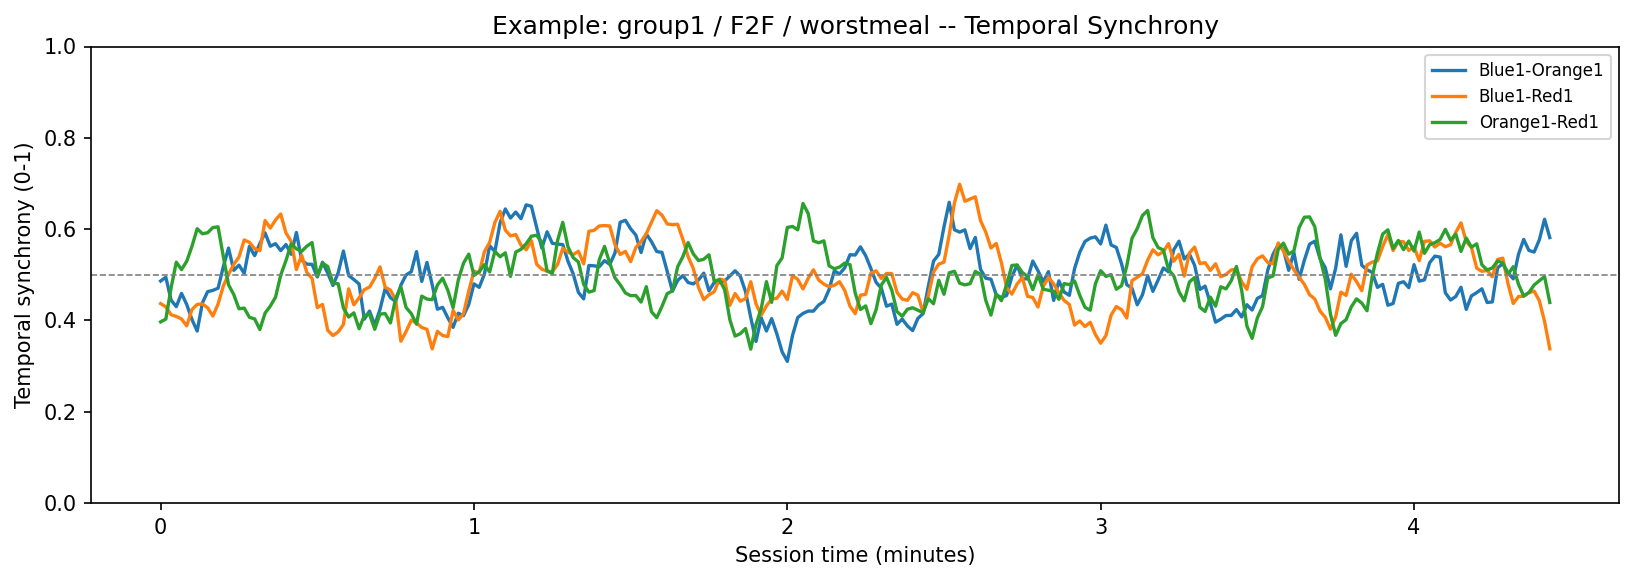

In [1]:
# Illustrative per-pair time series for one file (same style as the single-session notebook)
example = hybrid_long[(hybrid_long.group_id == 'group1') & (hybrid_long.condition == 'F2F') & (hybrid_long.task == 'worstmeal')]
hz = round(estimate_native_hz(example))
res = resample_session(example, rate_hz=hz)
ts = temporal_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S)
participants = sorted(example['participant_id'].unique())

fig, ax = plt.subplots(figsize=(11, 4))
for i, (pa, pb) in enumerate(all_pairs(participants)):
    sub = ts[(ts.participant_a == pa) & (ts.participant_b == pb)]
    roll = sub['synchrony'].rolling(10, center=True, min_periods=1).mean()
    ax.plot(sub['session_time_s'] / 60.0, roll, label=f'{pa}-{pb}', linewidth=1.6)
ax.axhline(0.5, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Session time (minutes)'); ax.set_ylabel('Temporal synchrony (0-1)')
ax.set_title('Example: group1 / F2F / worstmeal -- Temporal Synchrony'); ax.set_ylim(0, 1); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('hybrid_example_temporal_synchrony.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Locus-of-Focus export

Exports every ConfLab episode (both direction variants) and every hybrid
group/condition/task file as an LOF-ready pickle: floor-plane axis swap
(`position_y`&harr;`position_z`, `direction_y`&harr;`direction_z`), required
placeholder identity/state fields, and columns aligned to your
`group8_small_yesand.pkl` reference schema (62 columns).

Both source families are **already** "when they are in groups together"
segments (a ConfLab episode = one labeled F-formation's own time window; a
hybrid file = one group's dyad/triad for one condition/task) -- no further
slicing needed, so `get_segment` below is a straight lookup rather than a
time-range cut out of a larger source.

In [1]:
REF_COLS = list(pd.read_pickle(REF_PKL).columns)
print(f'Reference schema: {len(REF_COLS)} columns (from {REF_PKL.name})')

LOF_DIR = DATA_DIR / 'locus_ready'
(LOF_DIR / 'conflab_head').mkdir(parents=True, exist_ok=True)
(LOF_DIR / 'conflab_shoulders').mkdir(parents=True, exist_ok=True)
(LOF_DIR / 'hybrid').mkdir(parents=True, exist_ok=True)

exported = []

# --- ConfLab: one LOF pickle per episode per direction variant ---
for variant, ep_dir in [('conflab_head', DATA_DIR / 'conflab_head'), ('conflab_shoulders', DATA_DIR / 'conflab_shoulders')]:
    for p in sorted(ep_dir.glob('conflab_ep*.pkl')):
        raw = read_raw_conflab_episode(p)
        out_path = LOF_DIR / variant / p.name
        df_lof = export_lof_pickle(raw, REF_COLS, out_path)
        exported.append(str(out_path.relative_to(DATA_DIR)))
        print(f'  saved: {out_path.relative_to(DATA_DIR)}  ({len(df_lof)} rows, '
              f'{df_lof["uuid"].nunique()} participants, {len(df_lof.columns)} cols)')

# --- Hybrid: one LOF pickle per group/condition/task file ---
for p in sorted((DATA_DIR / 'hybrid').glob('group*.csv')):
    raw = read_raw_hybrid_file(p)
    out_path = LOF_DIR / 'hybrid' / (p.stem + '.pkl')
    df_lof = export_lof_pickle(raw, REF_COLS, out_path)
    exported.append(str(out_path.relative_to(DATA_DIR)))
    print(f'  saved: {out_path.relative_to(DATA_DIR)}  ({len(df_lof)} rows, '
          f'{df_lof["uuid"].nunique()} participants, {len(df_lof.columns)} cols)')

print(f'\nExported {len(exported)} LOF-ready pickles -> {LOF_DIR}')

Reference schema: 62 columns (from group8_small_yesand.pkl)
  saved: locus_ready/conflab_head/conflab_ep00_2_15_17_32.pkl  (86164 rows, 4 participants, 62 cols)
  saved: locus_ready/conflab_head/conflab_ep01_7_9_36_37.pkl  (80164 rows, 4 participants, 62 cols)
  saved: locus_ready/conflab_head/conflab_ep02_4_33_42.pkl  (59853 rows, 3 participants, 62 cols)
  saved: locus_ready/conflab_head/conflab_ep03_5_12_23.pkl  (42573 rows, 3 participants, 62 cols)
  saved: locus_ready/conflab_head/conflab_ep04_30_31_35.pkl  (34743 rows, 3 participants, 62 cols)
  saved: locus_ready/conflab_head/conflab_ep05_26_27_28.pkl  (32223 rows, 3 participants, 62 cols)
  saved: locus_ready/conflab_head/conflab_ep06_13_21_24.pkl  (30603 rows, 3 participants, 62 cols)
  saved: locus_ready/conflab_head/conflab_ep07_6_8_25.pkl  (27363 rows, 3 participants, 62 cols)
  saved: locus_ready/conflab_head/conflab_ep08_11_14_22.pkl  (25653 rows, 3 participants, 62 cols)
  saved: locus_ready/conflab_head/conflab_ep09_13_

## 8. Summary

In [1]:
print('=== ConfLab ===')
print(f"Within-formation:  mean={formation_dists['within'].mean():.3f} m  (n={len(formation_dists['within']):,})")
print(f"Cross-formation:   mean={formation_dists['cross'].mean():.3f} m  (n={len(formation_dists['cross']):,})")
print(f"Mean temporal synchrony across {len(conflab_synchrony)} episodes: {conflab_synchrony['temporal_sync_mean'].mean():.3f}")
print(f"Mean social synchrony (r) across {len(conflab_synchrony)} episodes: {conflab_synchrony['social_sync_mean_r'].mean():.3f}")
print()
print('=== Hybrid ===')
for (task, cond), d in hybrid_dists.items():
    print(f"  {task:14s} {LEGEND_LABEL[cond]:6s}: mean={d.mean():.3f} m  (n={len(d):,})")
print()
print(f'=== Locus of Focus ===')
print(f'{len(exported)} pickles exported to Data/locus_ready/ (34 conflab episode files + 24 hybrid files)')

=== ConfLab ===
Within-formation:  mean=1.450 m  (n=27,327)
Cross-formation:   mean=3.115 m  (n=751,233)
Mean temporal synchrony across 17 episodes: 0.506
Mean social synchrony (r) across 17 episodes: 0.013

=== Hybrid ===
  introductions  F2F   : mean=0.941 m  (n=6,050)
  introductions  6-1   : mean=0.836 m  (n=5,970)
  introductions  2-2-2 : mean=0.934 m  (n=5,610)
  worstmeal      F2F   : mean=0.935 m  (n=35,340)
  worstmeal      6-1   : mean=0.930 m  (n=32,676)
  worstmeal      2-2-2 : mean=0.874 m  (n=33,060)

=== Locus of Focus ===
58 pickles exported to Data/locus_ready/ (34 conflab episode files + 24 hybrid files)
